# Import neceassary Libraries
cv2: OpenCV for image processing.

os: For creating directories and managing file paths.

numpy: Numerical operations.

matplotlib.pyplot: Display images using Python plots.

In [2]:
import cv2 
import os
import numpy as np
import matplotlib.pyplot as plt

# Image Processing

## Read images

In [4]:
gray = cv2.imread('GRAY.JPG', cv2.IMREAD_GRAYSCALE) # high resolution panchromatic graysacle image
rgb_half = cv2.imread('RGB_half.JPG') # Roatated RGB image with lower resolution
rgb_quarter = cv2.imread('RGB_quater.JPG') # Rotated RGB image with even lower resolution

OpenCV reads images in BGR format, but matplotlib expects RGB — so we convert.

In [5]:
#Convert BGR format of cv2 into RGB
rgb_half_rgb = cv2.cvtColor(rgb_half, cv2.COLOR_BGR2RGB)
rgb_quarter_rgb = cv2.cvtColor(rgb_quarter, cv2.COLOR_BGR2RGB)

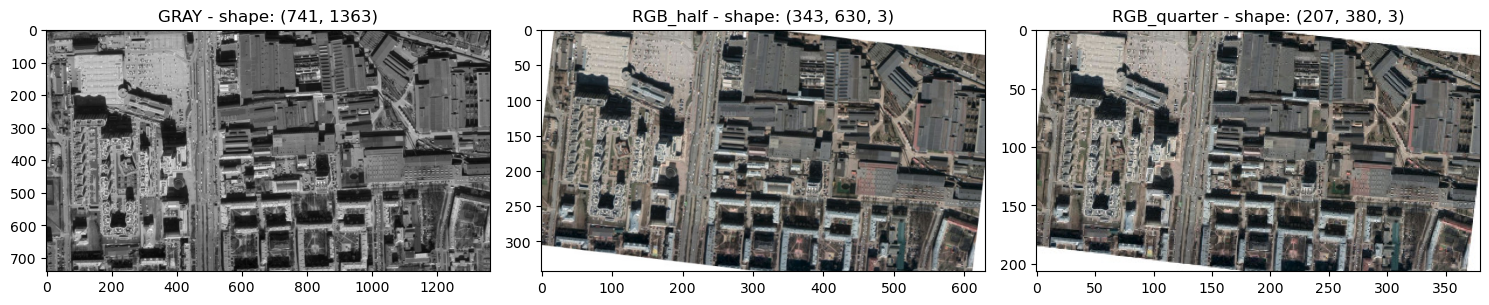

In [6]:
# Display images and shapes
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title(f'GRAY - shape: {gray.shape}')

plt.subplot(1, 3, 2)
plt.imshow(rgb_half_rgb)
plt.title(f'RGB_half - shape: {rgb_half.shape}')

plt.subplot(1, 3, 3)
plt.imshow(rgb_quarter_rgb)
plt.title(f'RGB_quarter - shape: {rgb_quarter.shape}')

plt.tight_layout()
plt.show()

## Align Rotated Images using ORB

Conversion into grayscale is needed for ORB feature extraction, which works on single-channel grayscale images.

In [8]:
#Convert rotated images into grayscale
rgb_half_gray = cv2.cvtColor(rgb_half, cv2.COLOR_BGR2GRAY)
rgb_quarter_gray = cv2.cvtColor(rgb_quarter, cv2.COLOR_BGR2GRAY)

Feature Detection with ORB. Detects keypoints + descriptors.
keypoints - locations ; 
descriptors - feature vectors , 
For both RGBs

In [9]:
MAX_NUM_FEATURES = 5000
orb = cv2.ORB_create(MAX_NUM_FEATURES)
keypoints1, descriptors1 = orb.detectAndCompute(rgb_half_gray, None)
keypoints2, descriptors2 = orb.detectAndCompute(rgb_quarter_gray, None)

Visually display where the Keypoints are located

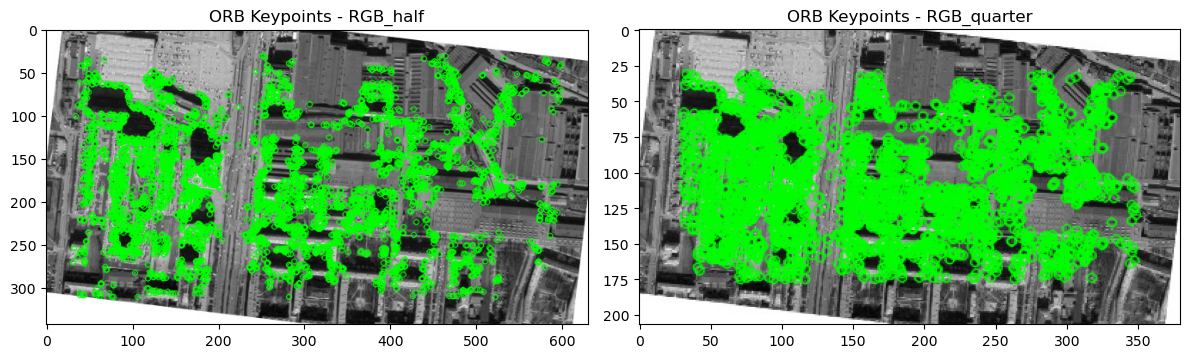

In [10]:
# Draw keypoints on both RGB_half and RGB_quarter iamges
rgb_half_kp = cv2.drawKeypoints(rgb_half_gray, keypoints1, None, color=(0, 255, 0))
rgb_quarter_kp = cv2.drawKeypoints(rgb_quarter_gray, keypoints2, None, color=(0, 255, 0))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_half_kp, cmap='gray')
plt.title("ORB Keypoints - RGB_half")

plt.subplot(1, 2, 2)
plt.imshow(rgb_quarter_kp, cmap='gray')
plt.title("ORB Keypoints - RGB_quarter")

plt.tight_layout()
plt.show()

## GRAY and RGB_half_gray

Complete the feature detection in the gray image as well

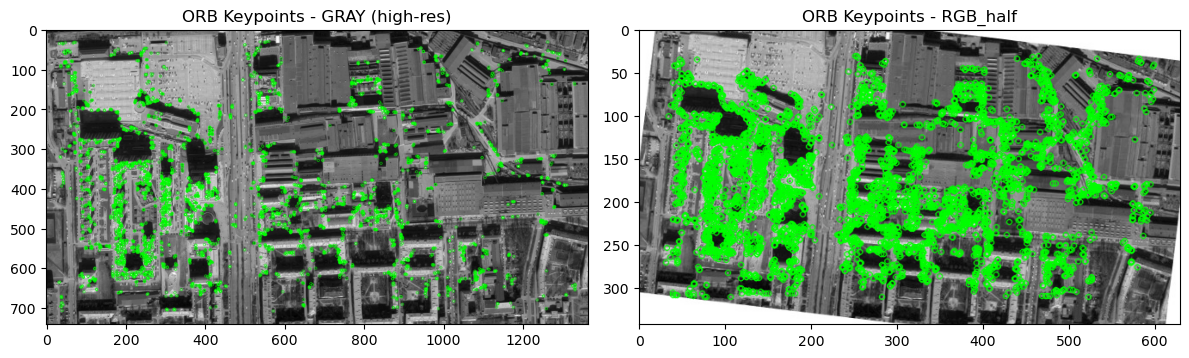

In [12]:
# Detect and draw keypoints for GRAY image
keypoints_gray, descriptors_gray = orb.detectAndCompute(gray, None)
gray_kp = cv2.drawKeypoints(gray, keypoints_gray, None, color=(0, 255, 0))

# display gray image alongside rgb_half
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_kp, cmap='gray')
plt.title("ORB Keypoints - GRAY (high-res)")

plt.subplot(1, 2, 2)
plt.imshow(rgb_half_kp, cmap='gray')
plt.title("ORB Keypoints - RGB_half")

plt.tight_layout()
plt.show()

Match Descriptors of Gray and RGB_half images

In [74]:
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)

matches = list(matcher.match(descriptors_gray, descriptors1, None)) # Converting to list for sorting as tuples - immutable objects.

matches.sort(key = lambda x: x.distance, reverse = False)

# Keep only top 10% of matches. (smallest distances)
numGoodMatches = int(len(matches) * 0.1)
matches = matches[:numGoodMatches]

<Figure size 4000x1000 with 0 Axes>

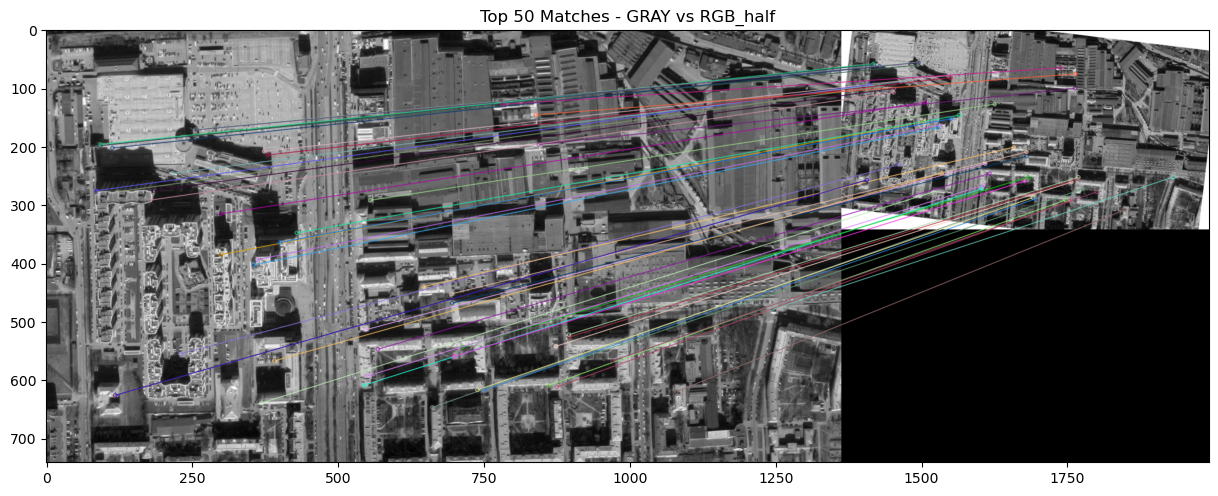

In [14]:
# Draw top matches
matched_img = cv2.drawMatches(gray, keypoints_gray, rgb_half_gray, keypoints1, matches[:50], None, flags=2)

plt.figure(figsize = [40, 10])

plt.figure(figsize=(15, 6))
plt.imshow(matched_img, cmap='gray')
plt.title('Top 50 Matches - GRAY vs RGB_half')
plt.show()

In [15]:
# Extract location of good matches
points_gray = np.zeros((len(matches), 2), dtype=np.float32)
points_half = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points_gray[i, :] = keypoints_gray[match.queryIdx].pt
    points_half[i, :] = keypoints1[match.trainIdx].pt  # keypoints1 = RGB_half

# Find homography from RGB_half to GRAY
H, mask = cv2.findHomography(points_half, points_gray, cv2.RANSAC)

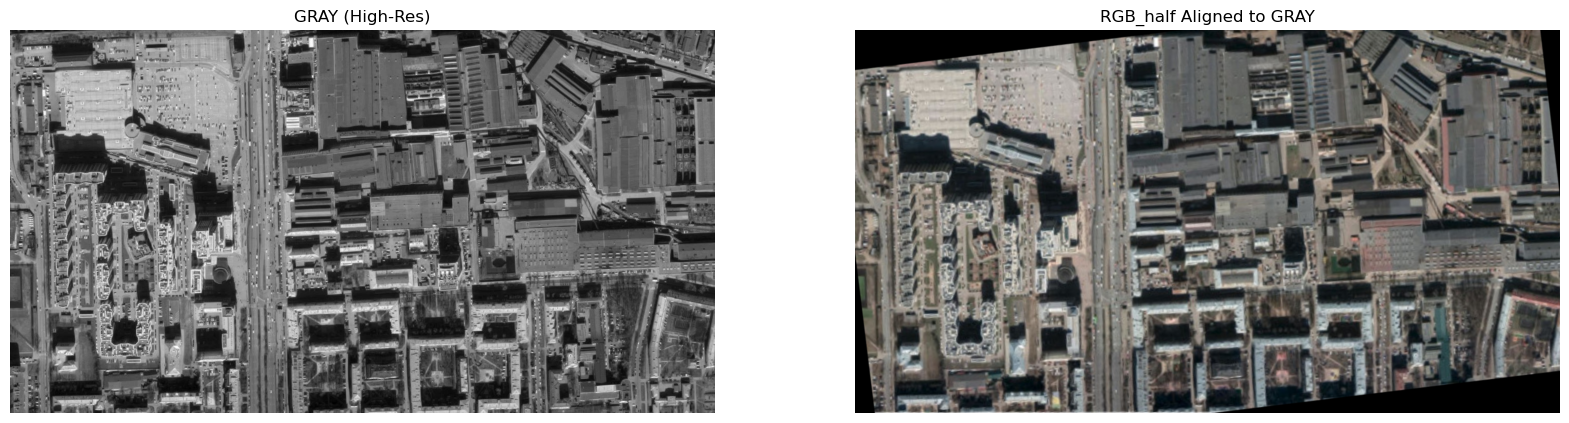

In [16]:
# Warp RGB_half image
height, width = gray.shape
rgb_half_aligned = cv2.warpPerspective(rgb_half, H, (width, height))

# Display result
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.axis("off")
plt.title("GRAY (High-Res)")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(rgb_half_aligned, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("RGB_half Aligned to GRAY")

plt.show()

Visually, it can be notices that streets and roofs are more aligned with each other.

Repeat the same thought process with GRAY and RGB_quarter

In [19]:
matches_q = list(matcher.match(descriptors_gray, descriptors2, None))
matches_q.sort(key=lambda x: x.distance)

numGoodMatches_q = int(len(matches_q) * 0.1)
matches_q = matches_q[:numGoodMatches_q]

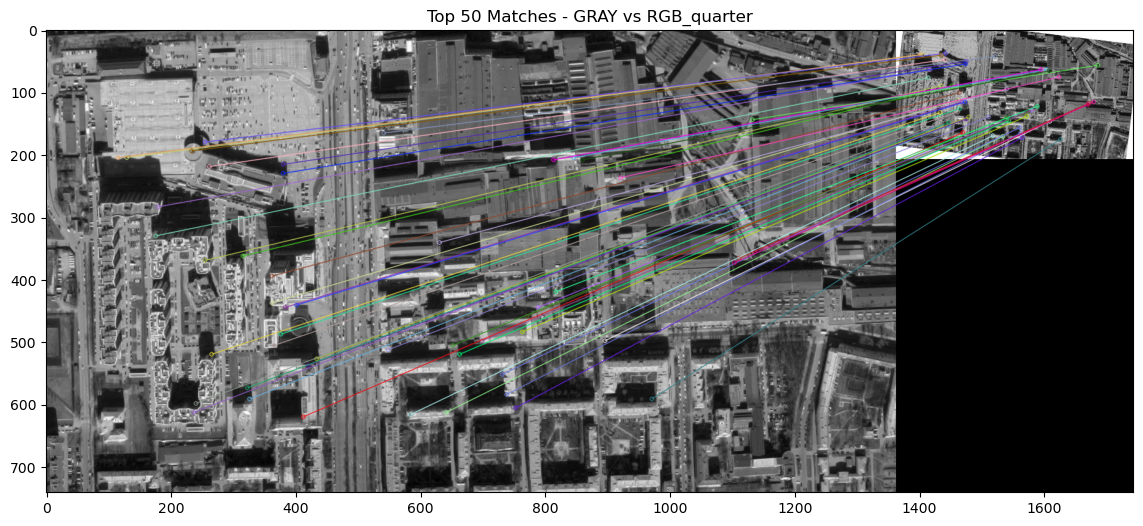

In [20]:
matched_img_q = cv2.drawMatches(gray, keypoints_gray, rgb_quarter_gray, keypoints2, matches_q[:50], None, flags=2)

plt.figure(figsize=(15, 6))
plt.imshow(matched_img_q, cmap='gray')
plt.title('Top 50 Matches - GRAY vs RGB_quarter')
plt.show()

In [21]:
# Extract good match locations
points_gray_q = np.zeros((len(matches_q), 2), dtype=np.float32)
points_quarter = np.zeros((len(matches_q), 2), dtype=np.float32)

for i, match in enumerate(matches_q):
    points_gray_q[i, :] = keypoints_gray[match.queryIdx].pt
    points_quarter[i, :] = keypoints2[match.trainIdx].pt  # keypoints2 = RGB_quarter

H_q, mask_q = cv2.findHomography(points_quarter, points_gray_q, cv2.RANSAC)
rgb_quarter_aligned = cv2.warpPerspective(rgb_quarter, H_q, (width, height))  # same width/height from before


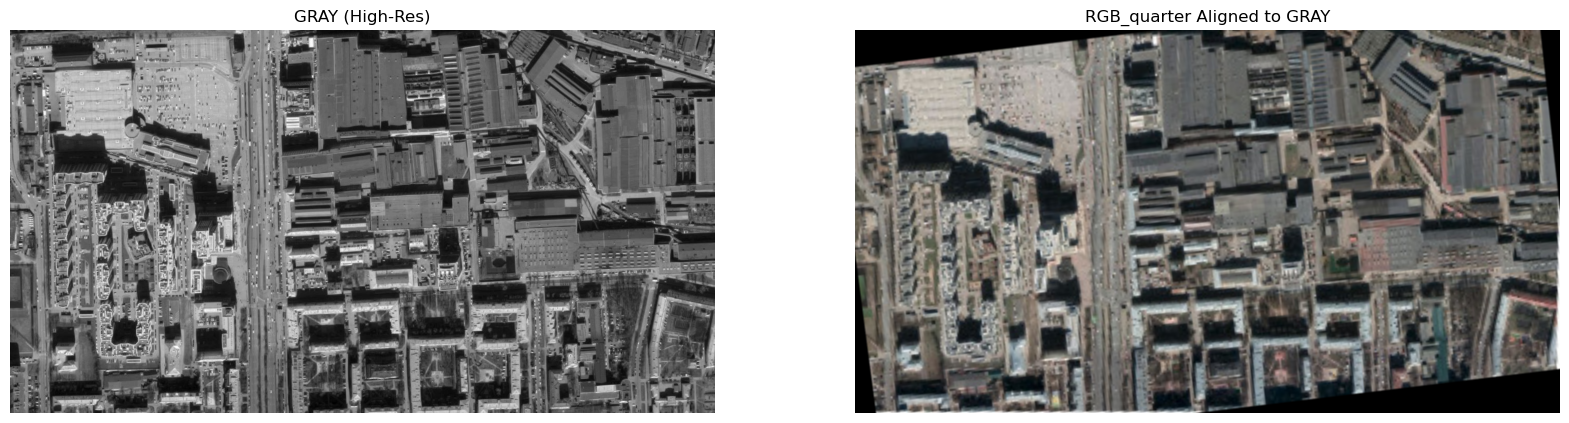

In [22]:
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.axis("off")
plt.title("GRAY (High-Res)")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(rgb_quarter_aligned, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("RGB_quarter Aligned to GRAY")

plt.show()

Resize aligned RGBs to GRAY image

In [24]:
# GRAY dimensions
height, width = gray.shape

# Resize aligned RGBs
rgb_half_resized = cv2.resize(rgb_half_aligned, (width, height), interpolation=cv2.INTER_LINEAR)
rgb_quarter_resized = cv2.resize(rgb_quarter_aligned, (width, height), interpolation=cv2.INTER_LINEAR)

print("Resized RGB_half shape:", rgb_half_resized.shape)
print("Resized RGB_quarter shape:", rgb_quarter_resized.shape)
print("GRAY shape:", gray.shape)

Resized RGB_half shape: (741, 1363, 3)
Resized RGB_quarter shape: (741, 1363, 3)
GRAY shape: (741, 1363)


Pan-shaprening: use RGB image's Hue and Saturation and replace the Value channgel with the high-resolution GRAY image. 

In [26]:
def pan_sharpen(gray, rgb_resized):
    hsv = cv2.cvtColor(rgb_resized, cv2.COLOR_BGR2HSV) # Convert RGB to HSV
    gray_norm = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX) # Normalize GRAY image to match V range [0,255]

    hsv[:,:,2] = gray_norm # Replace V channel with high-res grayscale image

    sharpened_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return sharpened_rgb

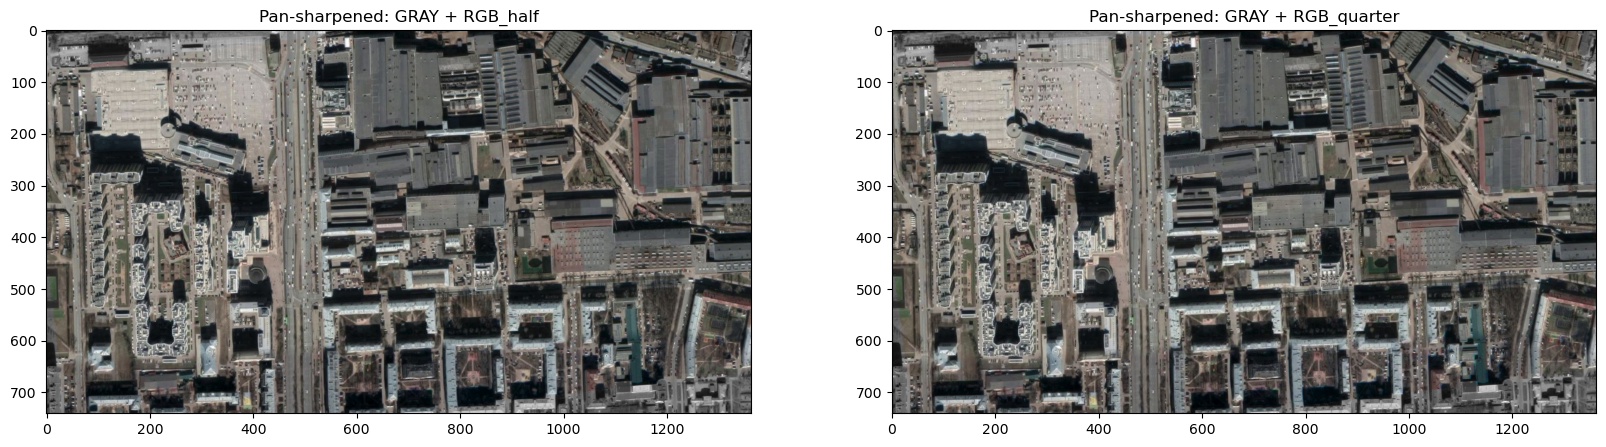

In [27]:
pan_sharp_half = pan_sharpen(gray, rgb_half_resized)
pan_sharp_quarter = pan_sharpen(gray, rgb_quarter_resized)

# Display results
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(pan_sharp_half, cv2.COLOR_BGR2RGB))
plt.title("Pan-sharpened: GRAY + RGB_half")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(pan_sharp_quarter, cv2.COLOR_BGR2RGB))
plt.title("Pan-sharpened: GRAY + RGB_quarter")

plt.show()

save the output files

In [29]:
output_dir = "pan_sharpened_outputs"
os.makedirs(output_dir, exist_ok=True)

In [30]:
# Define file paths
output_half_path = os.path.join(output_dir, "pan_sharpened_half.jpg")
output_quarter_path = os.path.join(output_dir, "pan_sharpened_quarter.jpg")

# Save using OpenCV (Note: OpenCV saves in BGR format)
cv2.imwrite(output_half_path, pan_sharp_half)
cv2.imwrite(output_quarter_path, pan_sharp_quarter)

print("Saved:")
print(" -", output_half_path)
print(" -", output_quarter_path)

Saved:
 - pan_sharpened_outputs\pan_sharpened_half.jpg
 - pan_sharpened_outputs\pan_sharpened_quarter.jpg


Visual Comparison

Pan-Sharpened version of RGB Half is more detailed compared to quarter RGB, which is a bit softer,  in terms of sharpness. Color consistency is more vibrant for Half RGB also. alignment is alsmost similar. Overall, pan_sharpened_half.jpg is visually superior, which is derived from the fact that source image RGB_half had better resolution and more pixels to execute sharpening with.